<a href="https://colab.research.google.com/github/yeatescp01/INFO648/blob/main/Lesson_08/Student_Copy_of_INFO_648_LSN8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  1. Supervised Machine Learning, Classification, and Logistic Regression

Supervised machine learning is a type of modeling where we train an algorithm using examples that include both input features and a known outcome (the target). The model learns patterns that map inputs to outputs so it can make predictions on new, unseen data. The goal is not to memorize the data, but to generalize patterns that work reasonably well on future observations.

Classification is a supervised learning task where the target variable takes on discrete categories rather than continuous values. In this class, we focus on binary classification, where the outcome is either 0 or 1.

Logistic regression is a classification algorithm that models the probability of an observation belonging to the positive class. Its main strength is interpretability and stability, but it struggles when relationships are highly nonlinear or when important features are missing.

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('cps_with_education_clean.csv')

In [3]:
df.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
0,197,2020,40,1350.0,43,1,23,Some College
1,224,2020,40,1310.0,64,2,23,Bachelor's
2,323,2020,40,1020.0,51,2,23,Graduate / Professional
3,324,2020,40,1350.0,52,1,23,Graduate / Professional
4,353,2020,50,1310.0,37,2,23,Some College


In [4]:
df.describe()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,2.476180e+05,247618.000000,247618.000000,247618.000000,247618.000000,247618.000000,247618.000000
mean,2.896190e+06,2023.358068,43.011150,2045.742057,44.728542,1.415289,27.981920
std,1.572192e+06,1.217079,7.245386,1478.484148,12.432250,0.492773,16.316574
min,1.970000e+02,2020.000000,21.000000,1002.000000,15.000000,1.000000,1.000000
25%,1.536342e+06,2022.000000,40.000000,1270.000000,35.000000,1.000000,12.000000
50%,2.928244e+06,2023.000000,40.000000,1630.000000,44.000000,1.000000,28.000000
75%,4.228782e+06,2024.000000,45.000000,2300.000000,54.000000,2.000000,42.000000
max,5.553888e+06,2025.000000,80.000000,13258.230000,85.000000,2.000000,56.000000


In [5]:
model_df=df.copy()

In [6]:
high_pay=model_df['EARNWEEK2'].median()

In [7]:
high_pay

1630.0

## 2. Defining the Target Variable: high_earner

We create a target variable called high_earner by labeling individuals who earn above the median weekly earnings as 1 and those at or below the median as 0. This converts a continuous income variable into a binary outcome that is suitable for classification.

Because high_earner can only take the values 0 or 1, it is a categorical target, not a numeric one, even though it is represented using numbers.

high\_earner =
\begin{cases}
1 & \text{if } \text{EARNWEEK2} > \text{median(EARNWEEK2)} \\
0 & \text{otherwise}
\end{cases}

In [8]:
model_df['high_earner']=(model_df['EARNWEEK2']>high_pay).astype(int)

In [9]:
model_df.head(15)

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education,high_earner
0,197,2020,40,1350.0,43,1,23,Some College,0
1,224,2020,40,1310.0,64,2,23,Bachelor's,0
2,323,2020,40,1020.0,51,2,23,Graduate / Professional,0
3,324,2020,40,1350.0,52,1,23,Graduate / Professional,0
4,353,2020,50,1310.0,37,2,23,Some College,0
5,362,2020,50,1210.0,53,2,23,Graduate / Professional,0
6,452,2020,60,1600.0,69,1,23,Master's,0
7,484,2020,50,2885.0,60,1,23,Graduate / Professional,1
8,493,2020,40,1080.0,56,1,23,Bachelor's,0
9,632,2020,40,1580.0,58,1,23,Associate's,0


In [10]:
model_df['high_earner'].value_counts()#balanced target

,count
high_earner,
0,125077
1,122541


In [11]:
from sklearn.model_selection import train_test_split
#Which ones go into the features and which go into the target?
#"AGE", "UHRSWORKT", "education", "SEX","high_earner"
X = model_df[["AGE", "UHRSWORKT", "education", "SEX","high_earner"]]
y = model_df['high_earner']




## 3. Train–Test Split

The train–test split divides the data into two separate sets: one used to train the model and one used to evaluate it. The model is allowed to learn only from the training data, while the test data is kept hidden until evaluation.

This separation helps us estimate how well the model will perform on new, unseen data and prevents us from overestimating model performance.





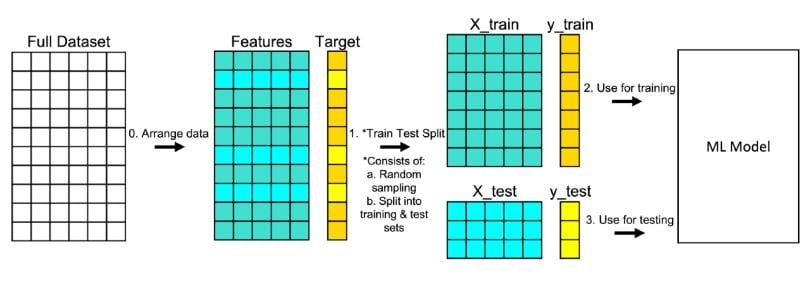

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
)

We use the following features to predict whether someone is a high earner:

features = ["AGE", "UHRSWORKT", "education", "SEX"]


* AGE – numeric (continuous)

* UHRSWORKT (usual hours worked per week) – numeric (continuous)

* education – categorical (levels of educational attainment)

* SEX – categorical

**Because our features include both numeric and categorical data, they must be processed differently before being used in a machine learning model.**

In [14]:
#which go into numeric and which go into categorical

#"AGE", "UHRSWORKT","education", "SEX"
numeric_features = ["AGE", "UHRSWORKT"]
categorical_features = ["education", "SEX"]


## Why We Scale Numeric Features

Logistic regression is sensitive to the scale of numeric features because it relies on optimization methods that depend on feature magnitude. If one feature has much larger values than another, it can dominate the learning process.

Min Max scaling rescales numeric features to the rage [0,1].


This ensures that all numeric variables contribute more evenly to the model.
$$
x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$


## One-Hot Encoding
Logistic regression requires numeric inputs and cannot directly interpret categorical values. One-hot encoding converts each category into a separate binary indicator variable:

x =
\begin{cases}
1 & \text{if the observation belongs to category } k \\
0 & \text{otherwise}
\end{cases}


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
#numeric_features
#categorical_features
preprocess = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


## What a Pipeline Does in scikit-learn

A pipeline combines preprocessing steps and the machine learning model into a single workflow. This ensures that all transformations learned from the training data are applied consistently to the test data.

Pipelines help prevent data leakage, simplify code, and reflect how models are built and deployed in real-world applications.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=2000))
    ]
)


In [17]:
model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['AGE', 'UHRSWORKT']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['education', 'SEX'])])),
                ('clf', LogisticRegression(max_iter=2000))])

## What model.fit() Does

Calling model.fit() trains the entire pipeline using the training data. During this step, preprocessing parameters (such as scaling ranges and category mappings) are learned, and the logistic regression model estimates its coefficients.

All learning occurs only on the training set, preserving the integrity of model evaluation.

In [18]:
#X_train, y_train
#X_test
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [19]:
y_pred

array([0, 1, 1, ..., 0, 1, 0])

In [20]:
############################################################
############## What Did Our Preprocessor do################
###########################################################
#Just so we can see what the preprocessor did to our data
X_processed = model.named_steps['preprocess'].transform(X_test)
df_preview = pd.DataFrame(X_processed, columns=model.named_steps['preprocess'].get_feature_names_out())

# Use display() for a pretty, scrollable table in Colab
display(df_preview.head())

,num__AGE,num__UHRSWORKT,cat__education_Associate's,cat__education_Bachelor's,cat__education_Graduate / Professional,cat__education_High School,cat__education_Less than HS,cat__education_Master's,cat__education_NIU / Child,cat__education_Some College,cat__SEX_1,cat__SEX_2
0,0.385714,0.322034,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.585714,0.661017,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.628571,0.406780,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.600000,0.491525,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.414286,0.322034,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [21]:
############################################################
############## What y_pred=model.predict do ################
###########################################################
#This is not part of our model - it is just to demonstrate what just happened!
results = X_test.copy()
results["y_test"] = y_test
results["y_pred"] = y_pred
results["prob_1"] = model.predict_proba(X_test)[:,1]

results

,AGE,UHRSWORKT,education,SEX,high_earner,y_test,y_pred,prob_1
60968,42,40,Master's,2,0,0,0,0.451172
3206,56,60,Associate's,1,0,0,1,0.579425
143558,59,45,Graduate / Professional,2,1,1,1,0.669338
15125,57,50,Bachelor's,1,0,0,1,0.521909
229089,44,40,Some College,1,1,1,0,0.301844
...,...,...,...,...,...,...,...,...
236258,39,40,Some College,1,0,0,0,0.283175
107963,51,40,Graduate / Professional,2,1,1,1,0.596160
59877,39,40,Less than HS,1,0,0,0,0.176750
197498,49,40,Graduate / Professional,1,1,1,1,0.723970


| Actual \\ Predicted | Predicted 0 (Negative) | Predicted 1 (Positive) |
|--------------------|------------------------|------------------------|
| **Actual 0 (Negative)** | True Negative (TN) | False Positive (FP) |
| **Actual 1 (Positive)** | False Negative (FN) | True Positive (TP) |


___________________________________________
___________________________________________

| Actual \\ Predicted | Not High Earner (0) | High Earner (1) |
|--------------------|--------------------|----------------|
| **Not High Earner (0)** | True Negative (TN) | False Positive (FP) |
| **High Earner (1)** | False Negative (FN) | True Positive (TP) |



In [22]:
from sklearn.metrics import confusion_matrix, classification_report
#Actual first
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred, digits=3))


[[19755 11438]
 [10555 20157]]
              precision    recall  f1-score   support

           0      0.652     0.633     0.642     31193
           1      0.638     0.656     0.647     30712

    accuracy                          0.645     61905
   macro avg      0.645     0.645     0.645     61905
weighted avg      0.645     0.645     0.645     61905



In [23]:
y_prob = model.predict_proba(X_test)[:, 1]


In [24]:
y_prob

array([0.45117216, 0.57942488, 0.66933752, ..., 0.17675037, 0.72396983,
       0.28822119])

In [26]:
y_pred_30 = (y_prob >= 0.3).astype(int)
print(confusion_matrix(y_test, y_pred_30))
print(classification_report(y_test, y_pred_30, digits=3))


[[ 7617 23576]
 [ 2405 28307]]
              precision    recall  f1-score   support

           0      0.760     0.244     0.370     31193
           1      0.546     0.922     0.685     30712

    accuracy                          0.580     61905
   macro avg      0.653     0.583     0.528     61905
weighted avg      0.654     0.580     0.526     61905

